# Practice Solutions

:::{admonition} Reference solutions
:class: note
Worked solutions for every exercise in [1.8-statistical-foundations-and-ml-practice-exercises.ipynb](1.8-statistical-foundations-and-ml-practice-exercises.ipynb).
:::

## Exercise 1: Explore

Build a DataFrame of 60 stations with `elevation_m` uniform on [200, 3500] and `temp_celsius = 15 - 6.5 * elevation_m/1000 + noise` (noise standard deviation 1.5 °C, seeded). Make a seaborn regression plot of temperature against elevation and print `describe()`.

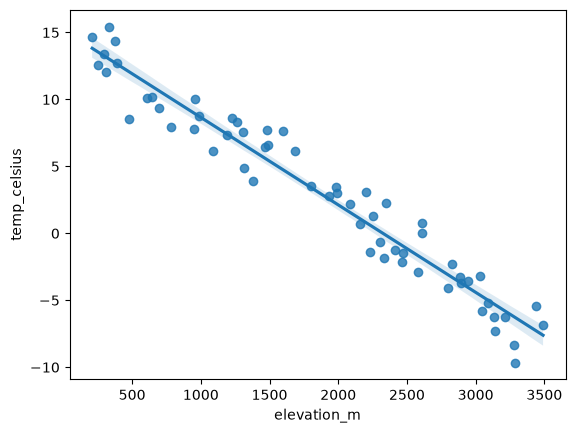

       elevation_m  temp_celsius
count        60.00         60.00
mean       1867.55          2.99
std         987.31          6.63
min         209.04         -9.66
25%        1065.20         -2.44
50%        1990.39          3.03
75%        2655.25          8.03
max        3490.79         15.43


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)
elev = rng.uniform(200, 3500, 60)
temp = 15 - 6.5 * (elev / 1000) + rng.normal(0, 1.5, 60)
df = pd.DataFrame({"elevation_m": elev, "temp_celsius": temp})
sns.regplot(data=df, x="elevation_m", y="temp_celsius")
plt.show()
print(df.describe().round(2))

## Exercise 2: Correlation

Print the Pearson correlation matrix of the DataFrame and identify the sign of the temperature–elevation correlation.

In [ ]:
print(df.corr().round(3))   # temperature vs elevation is strongly negative (the lapse rate)

              elevation_m  temp_celsius
elevation_m         1.000        -0.973
temp_celsius       -0.973         1.000


## Exercise 3: Fit a linear regression

Fit `LinearRegression` with `X = df[["elevation_m"]]` and `y = df["temp_celsius"]`. Print the recovered lapse rate in °C km⁻¹ and the intercept.

In [ ]:
from sklearn.linear_model import LinearRegression
X = df[["elevation_m"]]; y = df["temp_celsius"]
m = LinearRegression().fit(X, y)
print(round(m.coef_[0] * 1000, 2), "°C km^-1")
print(round(m.intercept_, 2), "°C")

-6.53 °C km^-1
15.18 °C


## Exercise 4: Honest evaluation

Split the data (test size 0.3, fixed random state), fit on the training set, and report the test RMSE and R^2.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
m = LinearRegression().fit(Xtr, ytr)
p = m.predict(Xte)
print("RMSE:", round(root_mean_squared_error(yte, p), 3))
print("R^2: ", round(r2_score(yte, p), 3))

RMSE: 1.35
R^2:  0.962


## Exercise 5: A pipeline with scaling

Build a `Pipeline` of `StandardScaler` followed by `LinearRegression`, fit it on the training set, and print its test R^2 (via `.score`).

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr, ytr)
print(round(pipe.score(Xte, yte), 3))

0.962


## Exercise 6: Demonstrate overfitting

Fit a degree-8 polynomial pipeline and compare its R^2 on training data with its R^2 on test data. `elevation_m` is in metres (order 10^2-10^3); an 8th-degree polynomial built directly on raw metres is numerically unstable rather than overfit, so rescale it to kilometres first (divide by 1000) — the same rescaling the lecture's own degree-8 demonstration relies on. A degree-8 polynomial has 9 parameters: fit on the full 42-point training set from Exercise 4, it is heavily over-determined and generalises fine instead of overfitting. Fit it on only the first 12 rows of the (already-shuffled) training set instead, matching the near-saturated regime — 12 points for 9 parameters — the lecture's own demonstration uses. Comment on the gap.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# elevation_m is in metres (order 1e3); an 8th-degree polynomial built directly on raw
# metres is numerically ill-conditioned rather than overfit, so rescale to kilometres
# first — the same fix the lecture's own degree-8 demonstration relies on
Xtr_km, Xte_km = Xtr / 1000, Xte / 1000

# shrinking the training set alone (down to 9-12 points) only produces a mild gap here,
# because the elevations are scattered randomly across the full range rather than evenly
# spaced -- a sparse interpolation gap does not reliably force wild swings. Train on only
# the LOWEST 30% of the elevation range instead: the model never sees anything above
# ~1.2 km, so every test point above that requires extrapolation, and a degree-8
# polynomial's error grows explosively outside the range it was fit on
low_idx = Xtr_km[Xtr_km["elevation_m"] < Xtr_km["elevation_m"].quantile(0.3)].index
Xtr_km_small, ytr_small = Xtr_km.loc[low_idx], ytr.loc[low_idx]

over = make_pipeline(PolynomialFeatures(degree=8), LinearRegression()).fit(Xtr_km_small, ytr_small)
print("train R^2:", round(over.score(Xtr_km_small, ytr_small), 3))
print("test  R^2:", round(over.score(Xte_km, yte), 3))
# a large train-test gap is overfitting: the flexible model memorised the low end of the
# range and never learned the shape of the data it was never shown

## Exercise 7: Cross-validation

Use `cross_val_score` with 5 folds to estimate the R^2 of a plain `LinearRegression` on the full dataset, and print the mean and standard deviation across folds.

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
print(round(scores.mean(), 3), round(scores.std(), 3))

0.938 0.013
